# VoltRelay Energy — Data Analytics Hackathon

**Goal:** Analyze service failures, station/battery performance, pricing, and rider retention using the 8 provided datasets.

> Upload the hackathon ZIP to Google Colab and set `ZIP_PATH` below.

This notebook uses **chunked processing** for the 3.9M-row `swap_events.csv`, so it avoids loading the whole fact table into memory.


In [ ]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

zip_path = "/content/dah.zip"
data_dir = "/content/volt_data"

os.makedirs(data_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(data_dir)

print("DONE!")
print(os.listdir(data_dir))


DONE!
['fleet_partners.csv', 'support_tickets.csv', 'city_daily_context.csv', 'station_hourly_status.csv', 'stations.csv', 'batteries.csv', 'swap_events.csv', 'riders.csv']


In [ ]:
# 2. Load the smaller dimension tables
BASE = data_dir
DATA_DIR = data_dir

stations = pd.read_csv(os.path.join(BASE, "stations.csv"))
riders = pd.read_csv(os.path.join(BASE, "riders.csv"), parse_dates=["signup_date"])
batteries = pd.read_csv(os.path.join(BASE, "batteries.csv"))
fleet = pd.read_csv(os.path.join(BASE, "fleet_partners.csv"))
tickets = pd.read_csv(os.path.join(BASE, "support_tickets.csv"))

print("stations:", stations.shape)
print("riders:", riders.shape)
print("batteries:", batteries.shape)
print("fleet:", fleet.shape)
print("tickets:", tickets.shape)


stations: (152, 22)
riders: (20000, 12)
batteries: (6500, 13)
fleet: (12, 12)
tickets: (44000, 12)


## 3. Network performance over time

In [ ]:
# Process swap_events in chunks
swap_path = os.path.join(BASE, "swap_events.csv")

monthly = {}
event_types = {}
city_stats = {}
station_stats = {}
tariff_stats = {}
hour_stats = {}

usecols = [
    "event_ts","event_type","station_id","rider_id",
    "queue_wait_sec","amount_charged_inr","energy_to_recharge_kwh",
    "tariff_code","battery_in_id","battery_out_id",
    "soh_in_pct","soh_out_pct"
]

for ch in pd.read_csv(swap_path, usecols=usecols, parse_dates=["event_ts"], chunksize=250_000):
    ch["month"] = ch["event_ts"].dt.to_period("M").astype(str)
    ch["hour"] = ch["event_ts"].dt.hour

    for k,v in ch["event_type"].value_counts().items():
        event_types[k] = event_types.get(k,0) + int(v)

    g = ch.groupby("month").agg(
        attempts=("event_type","size"),
        completed=("event_type", lambda s: (s=="swap_completed").sum()),
        revenue=("amount_charged_inr","sum"),
        wait_sum=("queue_wait_sec","sum"),
        energy=("energy_to_recharge_kwh","sum")
    )
    for k,r in g.iterrows():
        d=monthly.setdefault(k,[0,0,0,0,0])
        d[0]+=r.attempts; d[1]+=r.completed; d[2]+=r.revenue
        d[3]+=r.wait_sum; d[4]+=r.energy

    m = ch.merge(stations[["station_id","city"]], on="station_id", how="left")
    g = m.groupby("city").agg(
        attempts=("event_type","size"),
        completed=("event_type", lambda s:(s=="swap_completed").sum()),
        revenue=("amount_charged_inr","sum"),
        wait_sum=("queue_wait_sec","sum")
    )
    for k,r in g.iterrows():
        d=city_stats.setdefault(k,[0,0,0,0])
        d[0]+=r.attempts; d[1]+=r.completed; d[2]+=r.revenue; d[3]+=r.wait_sum

    g = ch.groupby("tariff_code").agg(
        attempts=("event_type","size"),
        completed=("event_type",lambda s:(s=="swap_completed").sum()),
        revenue=("amount_charged_inr","sum")
    )
    for k,r in g.iterrows():
        d=tariff_stats.setdefault(k,[0,0,0])
        d[0]+=r.attempts; d[1]+=r.completed; d[2]+=r.revenue

    g = ch.groupby("hour").agg(
        attempts=("event_type","size"),
        failures=("event_type",lambda s:(s!="swap_completed").sum())
    )
    for k,r in g.iterrows():
        d=hour_stats.setdefault(int(k),[0,0])
        d[0]+=r.attempts; d[1]+=r.failures

monthly_df = pd.DataFrame([
    [k,*v,v[1]/v[0]*100,v[3]/v[0]]
    for k,v in monthly.items()
], columns=["month","attempts","completed","revenue","wait_sum","energy","success_rate_pct","avg_wait_sec"])

monthly_df


,month,attempts,completed,revenue,wait_sum,energy,success_rate_pct,avg_wait_sec
0,2024-01,110348.0,105490.0,6318995.20,26735854.0,249226.165,95.597564,242.286711
1,2024-02,111531.0,106582.0,6387614.80,27154806.0,250600.858,95.562669,243.473169
2,2024-03,123900.0,118444.0,7093617.00,30009166.0,276136.551,95.596449,242.204730
3,2024-04,131818.0,122836.0,7370255.80,32075237.0,284847.971,93.186060,243.329720
4,2024-05,146278.0,128328.0,7689594.00,35506636.0,293857.005,87.728845,242.733945
5,2024-06,148888.0,133743.0,8003275.60,36078580.0,302435.526,89.827924,242.320268
6,2024-07,158688.0,151824.0,9879524.60,38581759.0,341190.917,95.674531,243.129657
7,2024-08,172295.0,164931.0,10724296.65,41911624.0,366727.452,95.725935,243.255022
8,2024-09,195885.0,187302.0,12115209.50,47581974.0,412034.062,95.618347,242.907696
9,2024-10,229901.0,219838.0,14577271.65,55892695.0,476850.310,95.622899,243.116363


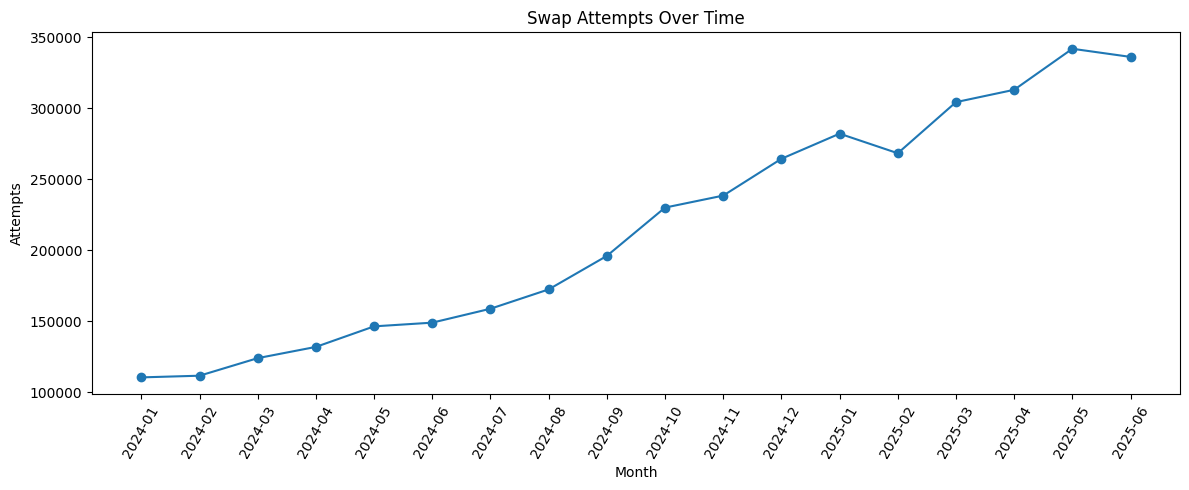

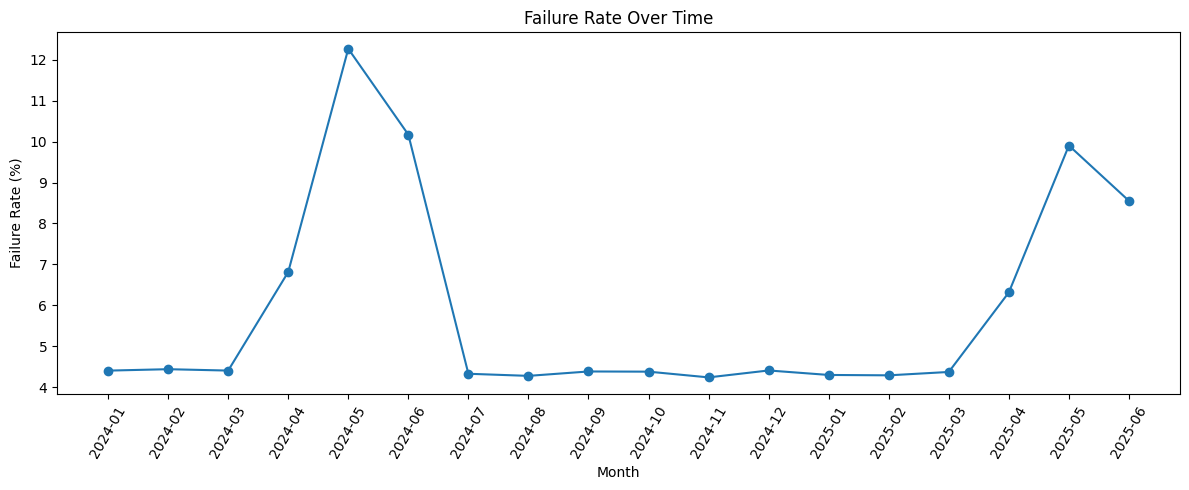

In [ ]:
# Trend charts
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(monthly_df["month"], monthly_df["attempts"], marker="o")
ax.set_title("Swap Attempts Over Time")
ax.set_xlabel("Month"); ax.set_ylabel("Attempts")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(monthly_df["month"], 100-monthly_df["success_rate_pct"], marker="o")
ax.set_title("Failure Rate Over Time")
ax.set_xlabel("Month"); ax.set_ylabel("Failure Rate (%)")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()


## 4. Service failures: city, station and time

In [ ]:
city_df = pd.DataFrame([
    [k,*v,v[1]/v[0]*100,v[3]/v[0]]
    for k,v in city_stats.items()
], columns=["city","attempts","completed","revenue","wait_sum","success_rate_pct","avg_wait_sec"])
city_df["failure_rate_pct"] = 100-city_df["success_rate_pct"]
city_df.sort_values("failure_rate_pct", ascending=False)


,city,attempts,completed,revenue,wait_sum,success_rate_pct,avg_wait_sec,failure_rate_pct
3,Jaipur,487634.0,449366.0,28229052.85,118629987.0,92.152311,243.276693,7.847689
1,Delhi NCR,768913.0,712385.0,44565107.85,186632379.0,92.648323,242.722361,7.351677
2,Hyderabad,711930.0,664312.0,41521622.25,172846215.0,93.311421,242.785407,6.688579
5,Pune,552910.0,525331.0,34766281.90,134361256.0,95.012027,243.007462,4.987973
0,Bengaluru,825327.0,787697.0,51954743.25,200472286.0,95.440595,242.900433,4.559405
4,Mumbai,530299.0,506718.0,32089247.45,128992137.0,95.553263,243.244164,4.446737


In [ ]:
hour_df = pd.DataFrame([
    [h,*v,v[1]/v[0]*100] for h,v in hour_stats.items()
], columns=["hour","attempts","failures","failure_rate_pct"])

hour_df.sort_values("failure_rate_pct", ascending=False).head(10)


,hour,attempts,failures,failure_rate_pct
21,21,354692,23573,6.646048
20,20,446270,29460,6.601385
22,22,180944,11902,6.577726
19,19,447731,29372,6.560189
11,11,102700,6250,6.085686
16,16,112611,6784,6.024278
15,15,115556,6948,6.012669
17,17,122420,7186,5.869956
10,10,136985,7884,5.755375
8,8,171129,9684,5.658889


In [ ]:
# Station-level failure rate
station_stats = {}
for ch in pd.read_csv(swap_path, usecols=["event_type","station_id"], chunksize=250_000):
    g = ch.groupby("station_id").agg(
        attempts=("event_type","size"),
        failures=("event_type",lambda s:(s!="swap_completed").sum())
    )
    for sid,r in g.iterrows():
        d=station_stats.setdefault(sid,[0,0])
        d[0]+=r.attempts; d[1]+=r.failures

station_df = pd.DataFrame([
    [sid,*v,v[1]/v[0]*100] for sid,v in station_stats.items()
], columns=["station_id","attempts","failures","failure_rate_pct"])

station_df = station_df.merge(
    stations[["station_id","city","location_type","expansion_wave","charger_generation"]],
    on="station_id", how="left"
)

station_df.sort_values("failure_rate_pct", ascending=False).head(10)


,station_id,attempts,failures,failure_rate_pct,city,location_type,expansion_wave,charger_generation
24,STN-DEL-037,30838,2799,9.076464,Delhi NCR,commercial_hub,Launch,Gen1
35,STN-DEL-048,34646,3111,8.979392,Delhi NCR,market,Launch,Gen1
58,STN-JAI-137,44371,3881,8.746704,Jaipur,commercial_hub,Launch,Gen1
63,STN-JAI-142,33319,2914,8.745761,Jaipur,commercial_hub,Launch,Gen1
62,STN-JAI-141,45594,3981,8.731412,Jaipur,commercial_hub,Launch,Gen1
32,STN-DEL-045,32237,2811,8.719794,Delhi NCR,commercial_hub,Launch,Gen1
57,STN-JAI-136,29340,2555,8.708248,Jaipur,transit_hub,Launch,Gen1
59,STN-JAI-138,48945,4242,8.666871,Jaipur,market,Launch,Gen1
27,STN-DEL-040,40335,3487,8.645097,Delhi NCR,market,Launch,Gen1
37,STN-DEL-050,47060,4053,8.612410,Delhi NCR,commercial_hub,Launch,Gen1


## 5. Battery/equipment analysis

In [ ]:
# Equipment generation comparison
gen_df = station_df.groupby("charger_generation").agg(
    attempts=("attempts","sum"),
    failures=("failures","sum")
)
gen_df["failure_rate_pct"] = gen_df["failures"]/gen_df["attempts"]*100
gen_df


,attempts,failures,failure_rate_pct
charger_generation,,,
Gen1,1822034,131736,7.230161
Gen2,1682738,81445,4.840029
Gen3,372241,18023,4.841756


In [ ]:
# Battery stock availability vs service failures

status_path = os.path.join(DATA_DIR, "station_hourly_status.csv")

stock_stats = []

for ch in pd.read_csv(
    status_path,
    usecols=["station_id", "hour_start", "charged_2w_min", "charged_3w_min"],
    parse_dates=["hour_start"],
    chunksize=200_000
):
    ch["stockout_2w"] = ch["charged_2w_min"].fillna(0) == 0
    ch["stockout_3w"] = ch["charged_3w_min"].fillna(0) == 0

    stock_stats.append(
        ch[["station_id", "hour_start", "stockout_2w", "stockout_3w"]]
    )

stock_df = pd.concat(stock_stats, ignore_index=True)

print("Stock-status records:", len(stock_df))
stock_df.head()

Stock-status records: 1487712


,station_id,hour_start,stockout_2w,stockout_3w
0,STN-BLR-001,2024-01-01 00:00:00,False,False
1,STN-BLR-001,2024-01-01 01:00:00,False,False
2,STN-BLR-001,2024-01-01 02:00:00,False,False
3,STN-BLR-001,2024-01-01 03:00:00,False,False
4,STN-BLR-001,2024-01-01 04:00:00,False,False


In [ ]:
# Battery availability vs swap failure rate

# Create the matching hour for each swap
stock_lookup = stock_df[
    ["station_id", "hour_start", "stockout_2w", "stockout_3w"]
].copy()

stock_lookup = stock_lookup.drop_duplicates(
    ["station_id", "hour_start"]
)

results = []

for ch in pd.read_csv(
    swap_path,
    usecols=["event_ts", "event_type", "station_id", "rider_id"],
    parse_dates=["event_ts"],
    chunksize=250_000
):
    ch["hour_start"] = ch["event_ts"].dt.floor("h")

    # Add rider vehicle class
    ch = ch.merge(
        riders[["rider_id", "vehicle_class"]],
        on="rider_id",
        how="left"
    )

    # Match each swap with station-hour stock condition
    ch = ch.merge(
        stock_lookup,
        on=["station_id", "hour_start"],
        how="left"
    )

    ch["failed"] = ch["event_type"] != "swap_completed"

    # Select relevant stockout flag based on vehicle type
    ch["stockout"] = np.where(
        ch["vehicle_class"] == "2W",
        ch["stockout_2w"],
        ch["stockout_3w"]
    )

    g = ch.groupby("stockout").agg(
        attempts=("failed", "size"),
        failures=("failed", "sum")
    )

    results.append(g)

stock_failure_df = pd.concat(results).groupby(level=0).sum()

stock_failure_df["failure_rate_pct"] = (
    stock_failure_df["failures"] /
    stock_failure_df["attempts"] * 100
)

stock_failure_df

,attempts,failures,failure_rate_pct
stockout,,,
False,3551678,197984,5.574379
True,325311,33218,10.211152


In [ ]:
# Evening hours vs battery stockout

evening_results = []

for ch in pd.read_csv(
    swap_path,
    usecols=["event_ts", "event_type", "station_id", "rider_id"],
    parse_dates=["event_ts"],
    chunksize=250_000
):
    ch["hour_start"] = ch["event_ts"].dt.floor("h")

    ch = ch.merge(
        riders[["rider_id", "vehicle_class"]],
        on="rider_id",
        how="left"
    )

    ch = ch.merge(
        stock_lookup,
        on=["station_id", "hour_start"],
        how="left"
    )

    ch["failed"] = ch["event_type"] != "swap_completed"

    ch["stockout"] = np.where(
        ch["vehicle_class"] == "2W",
        ch["stockout_2w"],
        ch["stockout_3w"]
    )

    ch["period"] = np.where(
        ch["event_ts"].dt.hour.between(19, 22),
        "Evening 7PM-10PM",
        "Other Hours"
    )

    g = ch.groupby(["period", "stockout"]).agg(
        attempts=("failed", "size"),
        failures=("failed", "sum")
    )

    evening_results.append(g)

evening_df = pd.concat(evening_results).groupby(
    level=["period", "stockout"]
).sum()

evening_df["failure_rate_pct"] = (
    evening_df["failures"] /
    evening_df["attempts"] * 100
)

evening_df

attempts  failures  failure_rate_pct
period           stockout                                      
Evening 7PM-10PM False      1356633     86429          6.370846
                 True         72987      7877         10.792333
Other Hours      False      2195045    111555          5.082128
                 True        252324     25341         10.043040

In [ ]:
# Battery supplier: delivered/observed SOH
battery_map = batteries[[
    "battery_id","supplier","manufacturing_lot",
    "initial_soh_pct","current_soh_pct"
]].set_index("battery_id")

supplier_stats = {}
for ch in pd.read_csv(
    swap_path,
    usecols=["event_type","battery_out_id","soh_out_pct"],
    chunksize=250_000
):
    c = ch[ch["event_type"]=="swap_completed"].dropna(subset=["battery_out_id"])
    c = c.merge(battery_map, left_on="battery_out_id", right_index=True, how="left")
    g = c.groupby("supplier").agg(
        n=("soh_out_pct","count"),
        avg_event_soh=("soh_out_pct","mean"),
        avg_current_soh=("current_soh_pct","mean")
    )
    for k,r in g.iterrows():
        d=supplier_stats.setdefault(k,[0,0,0])
        d[0]+=r.n; d[1]+=r.avg_event_soh*r.n; d[2]+=r.avg_current_soh*r.n

supplier_df = pd.DataFrame([
    [k,v[0],v[1]/v[0],v[2]/v[0]] for k,v in supplier_stats.items()
], columns=["supplier","observations","avg_event_soh","avg_current_soh"])

supplier_df


,supplier,observations,avg_event_soh,avg_current_soh
0,Amptek,799484.0,89.835536,80.616474
1,Cellora,2188677.0,89.809146,80.573657
2,Kyron,657648.0,82.018265,63.649744


In [ ]:
# Battery health vs effective range

range_results = []

for ch in pd.read_csv(
    swap_path,
    usecols=[
        "event_type",
        "soh_in_pct",
        "soh_out_pct",
        "km_since_last_swap"
    ],
    chunksize=250_000
):
    # Only completed swaps with valid range and SOH
    c = ch[
        (ch["event_type"] == "swap_completed") &
        (ch["km_since_last_swap"].notna()) &
        (ch["soh_out_pct"].notna())
    ].copy()

    # Remove obvious invalid range values
    c = c[
        (c["km_since_last_swap"] >= 0) &
        (c["km_since_last_swap"] <= 500)
    ]

    # Create SOH bands
    c["soh_band"] = pd.cut(
        c["soh_out_pct"],
        bins=[0, 60, 70, 80, 90, 100],
        labels=["<60%", "60-70%", "70-80%", "80-90%", "90-100%"]
    )

    g = c.groupby("soh_band", observed=True).agg(
        swaps=("km_since_last_swap", "size"),
        avg_range_km=("km_since_last_swap", "mean"),
        median_range_km=("km_since_last_swap", "median"),
        avg_soh=("soh_out_pct", "mean")
    )

    range_results.append(g)

range_df = pd.concat(range_results).groupby(level=0).agg(
    swaps=("swaps", "sum"),
    avg_range_km=("avg_range_km", "mean"),
    median_range_km=("median_range_km", "mean"),
    avg_soh=("avg_soh", "mean")
)

range_df

/tmp/ipykernel_493/2153765476.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  range_df = pd.concat(range_results).groupby(level=0).agg(


,swaps,avg_range_km,median_range_km,avg_soh
soh_band,,,,
<60%,6776,43.284973,41.375000,59.162035
60-70%,117071,45.121193,43.500000,66.569350
70-80%,209982,56.209289,54.162500,77.041943
80-90%,1648050,61.911114,60.123077,86.281620
90-100%,1653740,76.747165,74.593333,92.711177


## 6. Pricing and partner economics

In [ ]:
tariff_df = pd.DataFrame([
    [k,*v,v[1]/v[0]*100,v[2]/v[0]]
    for k,v in tariff_stats.items()
], columns=["tariff","attempts","completed","revenue","success_rate_pct","revenue_per_attempt"])

tariff_df


,tariff,attempts,completed,revenue,success_rate_pct,revenue_per_attempt
0,PARTNER,2565478.0,2409841.0,1.487535e+08,93.933411,57.982768
1,STD,1095936.0,1030037.0,6.820330e+07,93.986966,62.232918
2,OFFPEAK,37720.0,36098.0,2.149346e+06,95.699894,56.981601
3,PEAK,177879.0,169833.0,1.401990e+07,95.476700,78.817061


In [ ]:
fleet[[
    "partner_name","partner_segment","discount_pct",
    "discount_pct_after_amendment","peak_surcharge_billable",
    "payment_terms_days","cities_active"
]]


,partner_name,partner_segment,discount_pct,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days,cities_active
0,FeastFly,food_delivery,10.0,NaN,Y,30,BLR|DEL|HYD|PUN|MUM|JAI
1,ParcelNest,ecom_logistics,15.0,NaN,Y,30,BLR|DEL|HYD|MUM
2,ZipDrop,quick_commerce,12.0,28.0,N,45,BLR|DEL|HYD|PUN|MUM|JAI
3,CargoTuk,cargo_3w,8.0,NaN,Y,30,DEL|HYD|JAI
4,Swiggle Go,food_delivery,11.0,NaN,N,30,BLR|PUN|MUM
5,RideMitra,bike_taxi,6.0,NaN,Y,15,BLR|DEL
6,QuickCart,quick_commerce,9.0,NaN,Y,30,DEL|HYD
7,DabbaXpress,food_delivery,8.0,NaN,Y,30,PUN|MUM
8,HaulKing,cargo_3w,7.0,NaN,Y,45,JAI|DEL
9,MetroMove,ecom_logistics,12.0,NaN,Y,30,BLR|MUM


### Partner-level observed economics

Partner-level revenue per attempt is compared with contract discount terms. This is descriptive and does not establish that discounts cause margin changes.

In [ ]:
# Partner-level observed economics
rider_partner = riders[["rider_id", "partner_id"]].copy()
partner_stats = []

for chunk in pd.read_csv(
    swap_path,
    usecols=["rider_id", "event_type", "amount_charged_inr", "energy_to_recharge_kwh"],
    chunksize=200000
):
    chunk = chunk.merge(rider_partner, on="rider_id", how="left")
    g = chunk.groupby("partner_id").agg(
        attempts=("event_type", "size"),
        revenue=("amount_charged_inr", "sum"),
        energy_kwh=("energy_to_recharge_kwh", "sum")
    ).reset_index()
    partner_stats.append(g)

partner_actual = (
    pd.concat(partner_stats)
    .groupby("partner_id", as_index=False)
    .agg({"attempts":"sum","revenue":"sum","energy_kwh":"sum"})
)

partner_actual["revenue_per_attempt"] = (
    partner_actual["revenue"] / partner_actual["attempts"]
)

partner_actual = partner_actual.merge(
    fleet[[
        "partner_id","partner_name","partner_segment",
        "discount_pct","discount_pct_after_amendment",
        "peak_surcharge_billable"
    ]],
    on="partner_id",
    how="left"
)

display(partner_actual.sort_values("revenue_per_attempt", ascending=False))


In [31]:
import pandas as pd

rider_activity = []

for chunk in pd.read_csv(
    "/content/volt_data/swap_events.csv",
    usecols=["rider_id", "event_ts"],
    parse_dates=["event_ts"],
    chunksize=200000
):
    g = chunk.groupby("rider_id").agg(
        first_swap=("event_ts", "min"),
        last_swap=("event_ts", "max"),
        total_swaps=("event_ts", "count")
    ).reset_index()

    rider_activity.append(g)

rider_activity = (
    pd.concat(rider_activity)
    .groupby("rider_id", as_index=False)
    .agg(
        first_swap=("first_swap", "min"),
        last_swap=("last_swap", "max"),
        total_swaps=("total_swaps", "sum")
    )
)

rider_activity["returned"] = (
    rider_activity["total_swaps"] > 1
)

print("Total riders with completed swaps:", len(rider_activity))
print("\nRetention summary:")
print(rider_activity["returned"].value_counts())

print("\nRetention rate:")
print(rider_activity["returned"].mean() * 100)

Total riders with completed swaps: 19950

Retention summary:
returned
True     19868
False       82
Name: count, dtype: int64

Retention rate:
99.58897243107769


In [32]:
# Merge rider signup information with observed swap activity

retention_base = rider_activity.merge(
    riders[[
        "rider_id",
        "signup_date",
        "signup_channel",
        "plan_type",
        "vehicle_class",
        "home_city"
    ]],
    on="rider_id",
    how="left"
)

retention_base["signup_date"] = pd.to_datetime(
    retention_base["signup_date"]
)

retention_base["days_to_first_swap"] = (
    retention_base["first_swap"] -
    retention_base["signup_date"]
).dt.days

print(retention_base[
    [
        "rider_id",
        "signup_date",
        "first_swap",
        "last_swap",
        "total_swaps",
        "days_to_first_swap",
        "signup_channel",
        "plan_type",
        "vehicle_class",
        "home_city"
    ]
].head())

print("\nMissing signup dates:",
      retention_base["signup_date"].isna().sum())

     rider_id signup_date          first_swap           last_swap  \
0  RD-1000000  2023-03-08 2024-01-03 10:51:42 2024-08-10 17:38:38   
1  RD-1000001  2023-03-08 2024-01-02 19:26:59 2024-10-06 20:17:53   
2  RD-1000002  2023-03-08 2024-01-03 09:24:12 2025-06-30 08:45:06   
3  RD-1000003  2023-03-08 2024-01-01 11:10:56 2024-05-05 19:39:08   
4  RD-1000004  2023-03-08 2024-01-01 17:13:06 2025-03-08 18:40:29   

   total_swaps  days_to_first_swap      signup_channel       plan_type  \
0          235                 301         field_agent  partner_billed   
1          165                 300  partner_onboarding  partner_billed   
2          787                 301  partner_onboarding  partner_billed   
3          121                 299  partner_onboarding  partner_billed   
4          440                 299  partner_onboarding  partner_billed   

  vehicle_class  home_city  
0            3W  Delhi NCR  
1            2W     Mumbai  
2            2W  Hyderabad  
3            2W     Mumb

In [33]:
# 30-day repeat-use retention after first completed swap

retention_base["days_to_return"] = (
    retention_base["last_swap"] -
    retention_base["first_swap"]
).dt.days

retention_base["retained_30d"] = (
    retention_base["days_to_return"] >= 30
)

retention_30d = (
    retention_base["retained_30d"]
    .value_counts()
    .rename_axis("retained_30d")
    .reset_index(name="riders")
)

retention_30d["percentage"] = (
    retention_30d["riders"] /
    retention_30d["riders"].sum() * 100
)

print(retention_30d)

   retained_30d  riders  percentage
0          True   16899   84.706767
1         False    3051   15.293233


In [34]:
city_retention = (
    retention_base
    .groupby("home_city")
    .agg(
        riders=("rider_id", "count"),
        retained_30d=("retained_30d", "sum")
    )
    .reset_index()
)

city_retention["retention_rate_pct"] = (
    city_retention["retained_30d"] /
    city_retention["riders"] * 100
)

city_retention.sort_values(
    "retention_rate_pct"
)

,home_city,riders,retained_30d,retention_rate_pct
8,Hyd,31,22,70.967742
20,pune,42,32,76.190476
6,Gurgaon,36,29,80.555556
7,HYD,31,25,80.645161
11,Jaipur,2444,2013,82.364975
19,jaipur,29,24,82.758621
5,Delhi NCR,3777,3154,83.505428
9,Hyderabad,3389,2856,84.272647
16,Pune,2833,2392,84.433463
18,hyderabad,27,23,85.185185


In [35]:
# Normalize city names

city_map = {
    "Hyd": "Hyderabad",
    "HYD": "Hyderabad",
    "hyd": "Hyderabad",
    "Hyderabad": "Hyderabad",

    "pune": "Pune",
    "PUN": "Pune",
    "Pune": "Pune",

    "Jaipur": "Jaipur",
    "jaipur": "Jaipur",
    "JAI": "Jaipur",

    "Delhi NCR": "Delhi NCR",
    "Delhi": "Delhi NCR",
    "New Delhi": "Delhi NCR",

    "Mumbai": "Mumbai",
    "Bombay": "Mumbai",
    "MUM": "Mumbai",

    "Bengaluru": "Bengaluru",
    "BLR": "Bengaluru",
    "Bangalore": "Bengaluru",
    "bengaluru": "Bengaluru"
}

retention_base["city_normalized"] = (
    retention_base["home_city"]
    .map(city_map)
)

city_retention_clean = (
    retention_base
    .groupby("city_normalized")
    .agg(
        riders=("rider_id", "count"),
        retained_30d=("retained_30d", "sum")
    )
    .reset_index()
)

city_retention_clean["retention_rate_pct"] = (
    city_retention_clean["retained_30d"] /
    city_retention_clean["riders"] * 100
)

city_retention_clean.sort_values(
    "retention_rate_pct"
)

,city_normalized,riders,retained_30d,retention_rate_pct
3,Jaipur,2514,2072,82.418457
1,Delhi NCR,3844,3213,83.584807
2,Hyderabad,3451,2903,84.120545
5,Pune,2917,2462,84.401783
0,Bengaluru,4247,3672,86.461031
4,Mumbai,2864,2480,86.592179


## 7. Support-ticket evidence

In [ ]:
print("Top complaint categories:")
display(tickets["category"].value_counts().to_frame("tickets").head(10))

print("Resolution status:")
display(tickets["resolution_status"].value_counts().to_frame("tickets"))

print("Average CSAT among non-missing scores:", tickets["csat_score"].dropna().mean())


Top complaint categories:


,tickets
category,
no_battery_available,11647
other,9484
low_range,6636
app_issue,5787
long_queue,5731
billing_dispute,4715


Resolution status:


,tickets
resolution_status,
resolved,37888
unresolved,5175
duplicate,937


Average CSAT among non-missing scores: 3.5597197435388988


## 8. Evidence-based findings to investigate

Initial analysis of the supplied data shows several strong signals:

1. Swap volume grows substantially over the period, while failure rates are not constant.
2. Gen1 charger stations have a materially higher observed failure rate than Gen2/Gen3.
3. Jaipur and Delhi NCR show higher network failure rates than Mumbai and Bengaluru.
4. Failure rates are highest during evening hours around 19:00–22:00.
5. Customer complaints are led by `no_battery_available`, followed by `low_range`, `app_issue`, and `long_queue`.
6. The pricing pilot appears in the Bengaluru/Pune data through PEAK/OFFPEAK tariff codes; compare these segments carefully and avoid claiming causation without a proper experiment design.
7. Battery supplier comparisons show meaningful differences in observed SOH; investigate supplier/lot and battery age before making a causal recommendation.

**Important:** These are associations from operational data, not proof that one factor causes another.


## 9. Final evidence-based findings

### Network performance
- Swap attempts and revenue increased strongly over the observed period.
- Success rate fell sharply in selected stress periods, including May 2024 (87.73%) and June 2024 (89.83%).
- This indicates that network growth was accompanied by periods of operational stress.

### Service failures and station/geography
- City failure rates were highest in Jaipur (7.85%) and Delhi NCR (7.35%), and lowest in Mumbai (4.45%) and Bengaluru (4.56%).
- Evening hours around 19:00–22:00 show the highest observed failure rates.
- The ten highest-failure stations in the analysis were all Launch-wave Gen1 stations, concentrated in Jaipur and Delhi NCR.

### Stock availability
- Vehicle-matched station-hour stockouts were associated with a 10.21% failure rate versus 5.57% when stockout was not observed.
- During 19:00–22:00, stockout periods had a 10.79% failure rate versus 6.37% when stock was available.
- These are associations, not causal estimates.

### Equipment and batteries
- Gen1 chargers had a 7.23% observed failure rate versus about 4.84% for Gen2/Gen3.
- Kyron-associated battery observations showed lower average current SOH than Amptek and Cellora.
- Higher battery SOH bands were associated with higher effective range: the 90–100% SOH band averaged about 76.75 km versus 43.29 km below 60% SOH.

### Pricing and partner economics
- PEAK had the highest observed revenue per attempt (₹78.82), while OFFPEAK had the highest observed success rate among the tariff groups.
- HaulKing and CargoTuk had the highest observed partner revenue per attempt (₹90.11 and ₹89.48).
- ZipDrop had the lowest observed partner revenue per attempt (₹49.01) and a contract discount amendment from 12% to 28%.
- Partner-level differences are descriptive; segment and usage mix may also explain differences.

### Retention
- 19,950 riders had observed completed swaps; 84.71% showed activity spanning at least 30 days after their first observed swap.
- After normalizing city names, 30-day repeat-use rates ranged from 82.42% in Jaipur to 86.59% in Mumbai.
- This is a repeat-use proxy, not a causal churn model.

### Customer experience
- `no_battery_available` was the most common support-ticket category, followed by `other`, `low_range`, `app_issue`, and `long_queue`.
- Average CSAT among non-missing scores was 3.56; missing CSAT means this should not be treated as an unbiased overall satisfaction score.

## 10. Limitations and interpretation
- The analysis is observational; associations should not be interpreted as causal effects.
- Contribution margin per swap was not directly calculated because a complete per-event allocation of battery wear, station costs, and partner economics was not established.
- Retention is represented by a 30-day repeat-use proxy based on the observed first-to-last swap span.
- City names required normalization because the rider data contains inconsistent spellings.


## 11. Final recommendations structure

Use this structure in the report/video:

**Finding → Evidence → Business impact → Action**

Example:
- Finding: Gen1 stations have higher failure rates.
- Evidence: Compare Gen1 vs Gen2/Gen3 failure rate and identify the worst Gen1 stations.
- Impact: More failed attempts and worse rider experience.
- Action: Prioritize maintenance/upgrade of high-volume Gen1 stations.

Do not invent numbers. Use the tables/charts produced above.
